In [1]:
import sys
sys.path.insert(0, '../')
sys.path.insert(1, '../../')
from build_config import ALL_SEASONS, COMPETITIONS, CURRENT_SEASON, INPUT_CSV_PATHS, TARGET_RANGES
from const import REPO_PATH, RAW_DATA_PATH, PROCESSED_DATA_PATH, MODELS_PATH
from fbref_const import URLs, TARGET_COLUMNS

from src.data.match_data_processing import process_match_target_var, process_match_other_var
from src.feature.feature_encoders import *

import pandas as pd
import os
import numpy as np
import mlflow
import joblib
import tempfile
import os

from build_utils import *

In [2]:
key_columns=['date', 'home', 'away']

In [3]:
team_encoder_path = f"{MODELS_PATH}/data_processors/{COMPETITIONS[0]}/team_encoder.pkl"
encoder = TeamEncoder.load(team_encoder_path)

In [4]:
seasons=sorted(ALL_SEASONS)

In [5]:
test_dict=dict((k, pd.read_csv(f'{REPO_PATH}/{INPUT_CSV_PATHS[k]}')) for k in COMPETITIONS)

In [6]:
for competition in COMPETITIONS:
    test_dict[competition]['date']=pd.to_datetime(test_dict[competition]['date'], format='%Y-%m-%d')

In [7]:
all_features_dict={}
for competition in COMPETITIONS:
    if competition not in test_dict:
        continue
    test_df = test_dict[competition]
    team_encoder_path = f"{MODELS_PATH}/data_processors/{competition}/team_encoder.pkl"
    season_dfs_dict = {season: pd.read_csv(f"{PROCESSED_DATA_PATH}/{competition}/{season}/all_data_df.csv") for season in seasons}

    target_dfs = {season: pd.read_csv(f"{PROCESSED_DATA_PATH}/{competition}/{season}/all_target_df.csv") for season in seasons}
    # TeamEncoder features
    encoder = TeamEncoder.load(team_encoder_path)
    team_encoder_features = encoder.transform_spot(season_dfs_dict, test_df).reset_index(drop=True)

    # TeamLagFeatureGenerator features
    lag_feature_generator = TeamLagFeatureGenerator(lookback=5)
    team_lag_features = lag_feature_generator.transform_spot(season_dfs_dict, test_df).reset_index(drop=True)

    # PreviousSeasonTeamAverager features
    prev_season_averager = PreviousSeasonTeamAverager(decay_factor=1, date_col='date', home_col='home', away_col='away')
    prev_season_features = prev_season_averager.transform_spot(season_dfs_dict, test_df).reset_index(drop=True)

    # TeamRestDaysCalculator features
    rest_days_calculator = TeamRestDaysCalculator()
    rest_days_features = rest_days_calculator.transform_spot(season_dfs_dict, test_df).reset_index(drop=True)

    # TeamLagTargetFeature features
    lag_target_generator = TeamLagTargetFeature(lookback=5)
    lag_target_features = lag_target_generator.transform_spot(season_dfs_dict, target_dfs, test_df).reset_index(drop=True)

    # Merge all features on home, away, date
    from functools import reduce
    feature_dfs = [team_encoder_features, team_lag_features, prev_season_features, rest_days_features, lag_target_features]
    all_features = reduce(lambda left, right: pd.merge(left, right, on=['home', 'away', 'date'], how='outer'), feature_dfs)
    
    scaler = joblib.load(os.path.join(f"{MODELS_PATH}/data_processors/{competition}", 'standard_scaler.pkl'))
    all_features[scaler.feature_names_in_] = scaler.transform(all_features[scaler.feature_names_in_])

    all_features_dict[competition] = all_features.copy().fillna(-1)

Processing season: 2017-18
Processing season: 2018-19
Processing season: 2019-20
Processing season: 2020-21
Processing season: 2021-22
Processing season: 2022-23
Processing season: 2023-24
Processing season: 2024-25
Processing season: 2025-26


In [8]:
train_features=pd.read_csv(f"{REPO_PATH}/data/features/premier_league/all_combined_features_2017-24.csv")
train_features['date'] = pd.to_datetime(train_features['date'])
train_features = train_features.merge(all_features_dict['premier_league'][['home', 'away', 'date']], on=['home', 'away', 'date'], how='right').fillna(-1)

for competition, df in all_features_dict.items():
    all_features_dict[competition] = df[train_features.columns]

In [9]:
lag_target_features.columns

Index(['home', 'away', 'date', 'home_lag_1_was_home', 'home_lag_1_home_goals',
       'home_lag_1_away_goals', 'home_lag_1_home_corners',
       'home_lag_1_away_corners', 'home_lag_1_home_cards',
       'home_lag_1_away_cards',
       ...
       'away_lag_5_home_goals', 'away_lag_5_away_goals',
       'away_lag_5_home_corners', 'away_lag_5_away_corners',
       'away_lag_5_home_cards', 'away_lag_5_away_cards',
       'away_lag_5_home_shots', 'away_lag_5_away_shots',
       'away_lag_5_home_sots', 'away_lag_5_away_sots'],
      dtype='object', length=113)

In [10]:
model_dict={
    'premier_league': {
        'away_goals':{
            'run_id': '52ba3bb17f904629bddb9db2c8d19212',
            'artifact_path': 'model',
        },
        'home_goals':{
            'run_id': 'a1f26bb7bbf942f5873fc47000527aff',
            'artifact_path': 'model',
        },
    }
}

In [11]:
def load_joblib_model_from_mlflow(run_id, artifact_path, tracking_uri=None):
    """
    Fetch and load a joblib-dumped model from MLflow given experiment_id, run_id, and artifact_path.
    Optionally specify the MLflow tracking URI.
    Returns the loaded model.
    """
    if tracking_uri is not None:
        mlflow.set_tracking_uri(tracking_uri)
    client = mlflow.tracking.MlflowClient()
    # Download artifact to a temporary directory
    with tempfile.TemporaryDirectory() as tmp_dir:
        local_path = client.download_artifacts(run_id, artifact_path, tmp_dir)
        # Find the first .joblib file in the artifact directory
        for root, _, files in os.walk(local_path):
            for file in files:
                if file.endswith('.joblib'):
                    model_path = os.path.join(root, file)
                    return joblib.load(model_path)
        raise FileNotFoundError("No .joblib model file found in the artifact path.")


In [12]:
predictions={}

In [13]:
for competition in COMPETITIONS:
    predictions[competition] = {}
    for target_name in TARGET_RANGES:
        model = load_joblib_model_from_mlflow(model_dict[competition][target_name]['run_id'],
                                                model_dict[competition][target_name]['artifact_path'],
                                                f'{REPO_PATH}/mlflow')
        prediction = model.predict_proba(all_features_dict[competition].drop(columns=key_columns))
        prediction = pd.DataFrame(prediction, columns=list(range(TARGET_RANGES[target_name][0], TARGET_RANGES[target_name][1]+1))+['other'])
        predictions[competition][target_name]=prediction

/Users/tianqihuang/anaconda3/envs/betbot/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
# Add home, away, date columns from test_dict to each predictions DataFrame
for competition in predictions:
    test_rows = all_features_dict[competition][['home', 'away', 'date']].reset_index(drop=True)
    for target_name in predictions[competition]:
        df = predictions[competition][target_name]
        # Prepend home, away, date columns
        df = pd.concat([test_rows, df.reset_index(drop=True)], axis=1)
        predictions[competition][target_name] = df

# Example: predictions['premier_league']['home_goals'].head()

In [15]:
predictions['premier_league']['home_goals']

,home,away,date,0,1,2,3,4,5,other
0,Aston Villa,Crystal Palace,2025-08-31,0.236233,0.280872,0.205121,0.199100,0.054521,0.019032,0.005122
1,Brighton,Manchester City,2025-08-31,0.253629,0.228091,0.276921,0.146534,0.062926,0.029163,0.002736
2,Chelsea,Fulham,2025-08-30,0.194573,0.260343,0.232914,0.199894,0.047966,0.060311,0.003999
3,Leeds United,Newcastle Utd,2025-08-30,0.250708,0.493404,0.156083,0.064095,0.022394,0.011681,0.001635
4,Liverpool,Arsenal,2025-08-31,0.188556,0.268594,0.223225,0.213946,0.072297,0.029230,0.004152
5,Manchester Utd,Burnley,2025-08-30,0.151197,0.277794,0.220591,0.291235,0.047023,0.008518,0.003643
6,Nott'ham Forest,West Ham,2025-08-31,0.236106,0.327504,0.230908,0.123530,0.045304,0.033645,0.003003
7,Sunderland,Brentford,2025-08-30,0.288905,0.380754,0.149863,0.100339,0.068656,0.009252,0.002230
8,Tottenham,Bournemouth,2025-08-30,0.280167,0.191995,0.137887,0.263321,0.094981,0.029312,0.002337
9,Wolves,Everton,2025-08-30,0.226334,0.284508,0.271086,0.118609,0.065090,0.031361,0.003011


In [16]:
predictions['premier_league']['away_goals']

,home,away,date,0,1,2,3,4,5,6,other
0,Aston Villa,Crystal Palace,2025-08-31,0.209533,0.499752,0.225717,0.033676,0.013489,0.004140,0.011725,0.001969
1,Brighton,Manchester City,2025-08-31,0.195966,0.390141,0.234581,0.132140,0.029513,0.006089,0.008208,0.003362
2,Chelsea,Fulham,2025-08-30,0.262514,0.398016,0.206732,0.099086,0.016895,0.006138,0.008756,0.001862
3,Leeds United,Newcastle Utd,2025-08-30,0.146332,0.454712,0.246374,0.082468,0.035592,0.017405,0.014804,0.002314
4,Liverpool,Arsenal,2025-08-31,0.207977,0.409727,0.231503,0.067275,0.061601,0.005259,0.013611,0.003048
5,Manchester Utd,Burnley,2025-08-30,0.455750,0.365765,0.115650,0.042625,0.013265,0.002307,0.002951,0.001687
6,Nott'ham Forest,West Ham,2025-08-31,0.213641,0.406990,0.199836,0.106663,0.043571,0.007136,0.019648,0.002514
7,Sunderland,Brentford,2025-08-30,0.152386,0.325369,0.441740,0.049931,0.011675,0.012277,0.004833,0.001789
8,Tottenham,Bournemouth,2025-08-30,0.171638,0.418994,0.242658,0.116274,0.020902,0.008883,0.017842,0.002809
9,Wolves,Everton,2025-08-30,0.214078,0.436566,0.215412,0.089267,0.030239,0.004223,0.008340,0.001875


In [17]:
# Convert all column names in predictions DataFrames to string type
for competition in predictions:
    for target_name in predictions[competition]:
        df = predictions[competition][target_name]
        df.columns = [str(col) for col in df.columns]
        predictions[competition][target_name] = df

In [18]:
# Rename columns and update values in predictions DataFrames for each competition and target
import copy
acc_predictions = copy.deepcopy(predictions)
for competition in acc_predictions:
    for target_name in acc_predictions[competition]:
        df = acc_predictions[competition][target_name]
        cols = df.columns.tolist()
        # Only rename and update non-metadata columns (assume first three are home, away, date)
        meta_cols = ['home', 'away', 'date']
        feature_cols = cols[3:]
        # Rename columns: first becomes lte_{original}, others become gt_{previous}
        new_cols = meta_cols.copy()
        if feature_cols:
            new_cols.append(f"lte_{feature_cols[0]}")
            for i in range(1, len(feature_cols)):
                new_cols.append(f"gt_{feature_cols[i-1]}")
        # Update values: first feature column stays, others become sum of itself and all to the right
        arr = df[feature_cols].values.copy() if feature_cols else None
        if arr is not None and arr.shape[1] > 0:
            for i in range(1, arr.shape[1]):
                arr[:, i] = arr[:, i:].sum(axis=1)
            df = pd.concat([df[meta_cols].reset_index(drop=True), pd.DataFrame(arr, columns=new_cols[3:])], axis=1)
            df.columns = new_cols
            acc_predictions[competition][target_name] = df

# Example: predictions['premier_league']['home_goals'].head()

In [19]:
acc_predictions['premier_league']['home_goals']

,home,away,date,lte_0,gt_0,gt_1,gt_2,gt_3,gt_4,gt_5
0,Aston Villa,Crystal Palace,2025-08-31,0.236233,0.763767,0.482896,0.277775,0.078675,0.024154,0.005122
1,Brighton,Manchester City,2025-08-31,0.253629,0.746371,0.518280,0.241359,0.094825,0.031899,0.002736
2,Chelsea,Fulham,2025-08-30,0.194573,0.805427,0.545084,0.312169,0.112276,0.064310,0.003999
3,Leeds United,Newcastle Utd,2025-08-30,0.250708,0.749292,0.255888,0.099804,0.035710,0.013316,0.001635
4,Liverpool,Arsenal,2025-08-31,0.188556,0.811444,0.542850,0.319625,0.105679,0.033382,0.004152
5,Manchester Utd,Burnley,2025-08-30,0.151197,0.848803,0.571009,0.350418,0.059184,0.012161,0.003643
6,Nott'ham Forest,West Ham,2025-08-31,0.236106,0.763894,0.436390,0.205482,0.081951,0.036647,0.003003
7,Sunderland,Brentford,2025-08-30,0.288905,0.711095,0.330340,0.180478,0.080138,0.011482,0.002230
8,Tottenham,Bournemouth,2025-08-30,0.280167,0.719833,0.527837,0.389950,0.126630,0.031649,0.002337
9,Wolves,Everton,2025-08-30,0.226334,0.773666,0.489158,0.218071,0.099462,0.034372,0.003011


In [20]:
acc_predictions['premier_league']['away_goals']

,home,away,date,lte_0,gt_0,gt_1,gt_2,gt_3,gt_4,gt_5,gt_6
0,Aston Villa,Crystal Palace,2025-08-31,0.209533,0.790467,0.290716,0.064999,0.031323,0.017834,0.013694,0.001969
1,Brighton,Manchester City,2025-08-31,0.195966,0.804034,0.413894,0.179313,0.047172,0.017659,0.011570,0.003362
2,Chelsea,Fulham,2025-08-30,0.262514,0.737486,0.339470,0.132737,0.033651,0.016756,0.010618,0.001862
3,Leeds United,Newcastle Utd,2025-08-30,0.146332,0.853668,0.398956,0.152582,0.070115,0.034522,0.017118,0.002314
4,Liverpool,Arsenal,2025-08-31,0.207977,0.792023,0.382296,0.150793,0.083518,0.021917,0.016658,0.003048
5,Manchester Utd,Burnley,2025-08-30,0.455750,0.544250,0.178485,0.062836,0.020210,0.006945,0.004638,0.001687
6,Nott'ham Forest,West Ham,2025-08-31,0.213641,0.786359,0.379369,0.179533,0.072870,0.029298,0.022162,0.002514
7,Sunderland,Brentford,2025-08-30,0.152386,0.847614,0.522245,0.080505,0.030574,0.018899,0.006621,0.001789
8,Tottenham,Bournemouth,2025-08-30,0.171638,0.828362,0.409368,0.166710,0.050435,0.029534,0.020651,0.002809
9,Wolves,Everton,2025-08-30,0.214078,0.785922,0.349356,0.133945,0.044677,0.014438,0.010215,0.001875


In [21]:
import matplotlib.pyplot as plt
import math

def plot_predictions_distribution(predictions, competition, target_name, max_plots=10):
    df = predictions[competition][target_name]
    meta_cols = ['home', 'away', 'date']
    prob_cols = [col for col in df.columns if col not in meta_cols]
    n_plots = min(len(df), max_plots)
    
    # Calculate optimal grid dimensions ensuring rows >= cols
    n_cols = math.floor(math.sqrt(n_plots))
    n_rows = math.ceil(n_plots / n_cols)
    
    # Adjust if rows < cols
    if n_rows < n_cols:
        n_rows, n_cols = n_cols, n_rows
    
    # Create subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3*n_rows), squeeze=False)
    
    # Plot data
    for idx in range(n_plots):
        i, j = idx // n_cols, idx % n_cols
        row = df.iloc[idx]
        axes[i, j].bar(prob_cols, row[prob_cols])
        axes[i, j].set_ylabel('Probability')
        axes[i, j].set_title(f"{row['home']} vs\n{row['away']}\n({row['date']})")
        axes[i, j].tick_params(axis='x', rotation=45)
    
    # Hide empty subplots
    for idx in range(n_plots, n_rows * n_cols):
        i, j = idx // n_cols, idx % n_cols
        axes[i, j].axis('off')
    
    plt.tight_layout()
    plt.show()


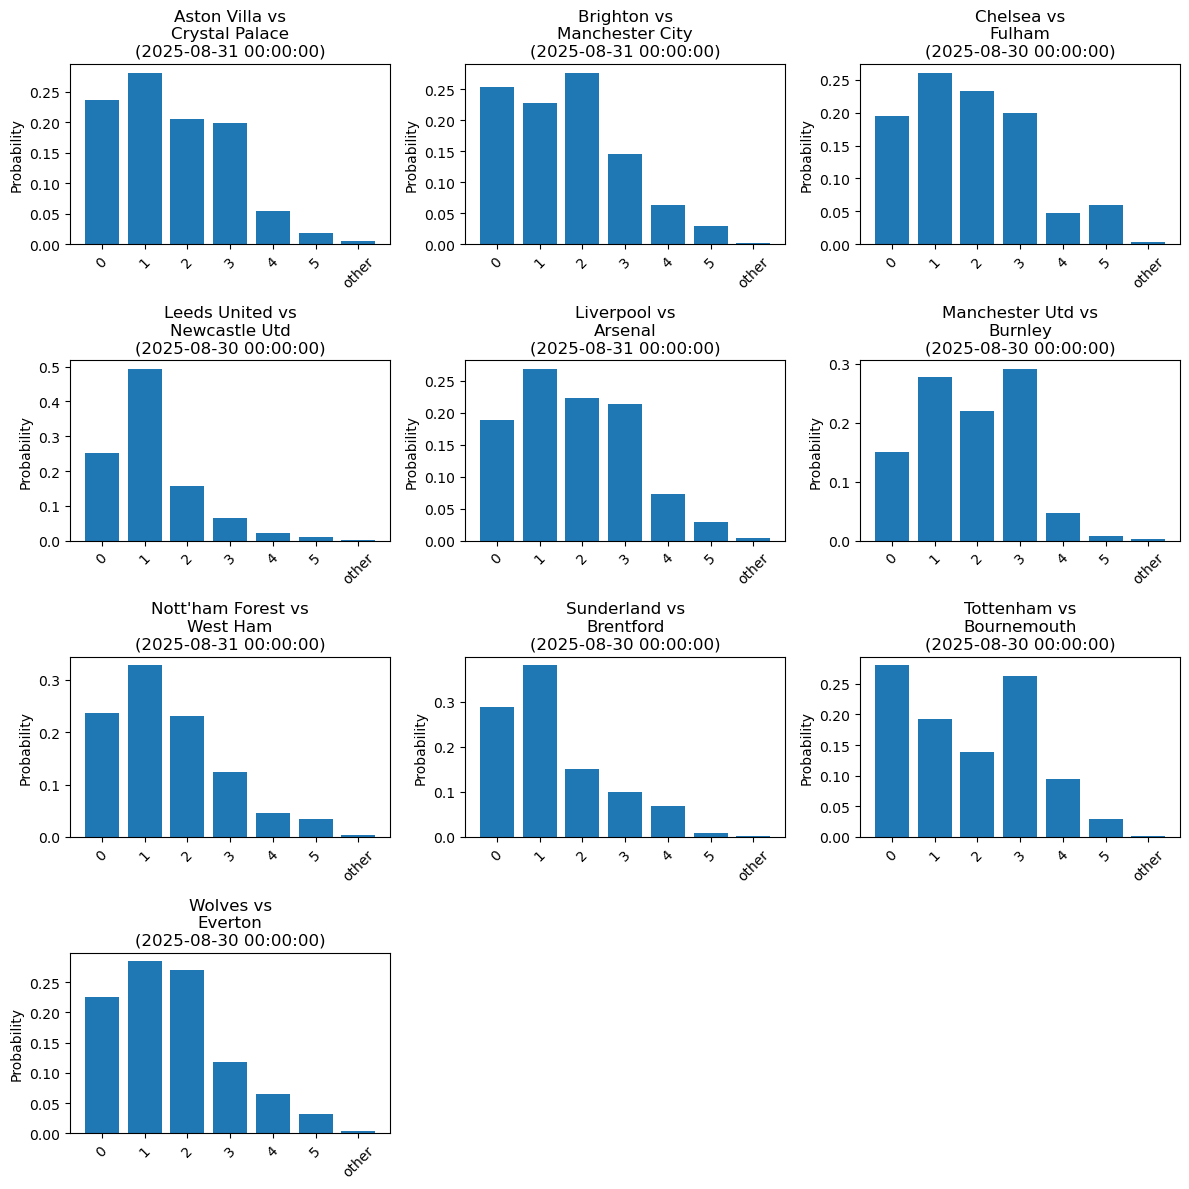

In [22]:
plot_predictions_distribution(predictions, 'premier_league', 'home_goals')

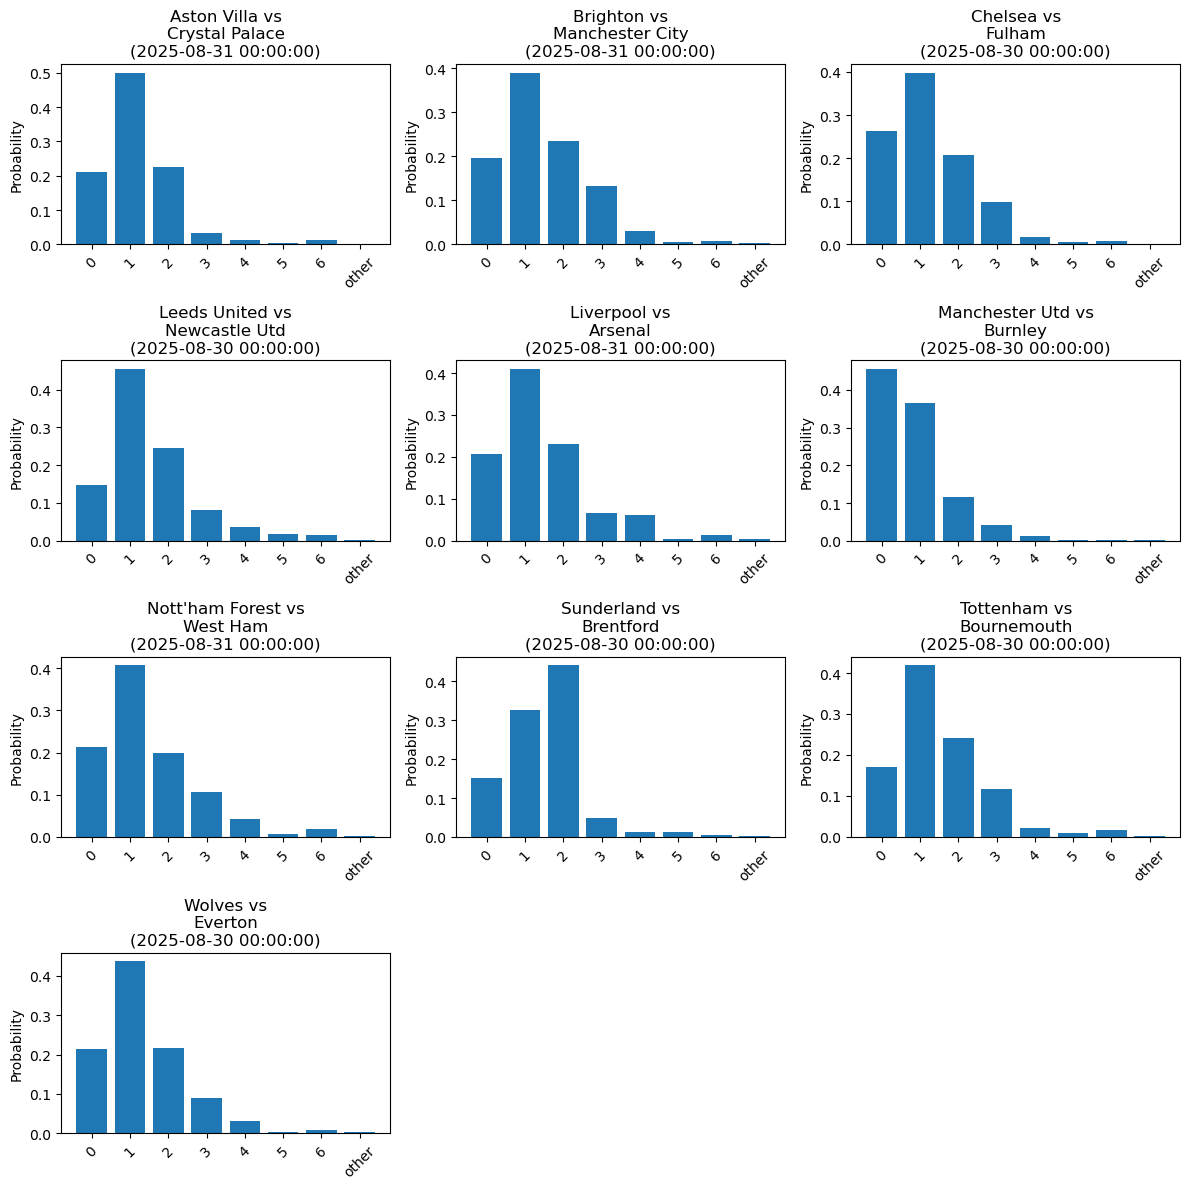

In [23]:
plot_predictions_distribution(predictions, 'premier_league', 'away_goals')

In [24]:
# Compute total goals probability distribution assuming independence
total_goals_predictions = {}

for competition in predictions:
    home_df = predictions[competition]['home_goals']
    away_df = predictions[competition]['away_goals']
    meta_cols = ['home', 'away', 'date']
    home_prob_cols = [col for col in home_df.columns if col not in meta_cols]
    away_prob_cols = [col for col in away_df.columns if col not in meta_cols]

    # Convert column names to int if possible, ignore 'other'
    home_goal_vals = [int(col) for col in home_prob_cols if col != 'other']
    away_goal_vals = [int(col) for col in away_prob_cols if col != 'other']

    max_home = max(home_goal_vals)
    max_away = max(away_goal_vals)
    max_total = max_home + max_away

    total_goal_vals = list(range(0, max_total+1))
    total_goal_dist = []

    for idx in range(len(home_df)):
        home_probs = home_df.loc[idx, [str(g) for g in home_goal_vals]].values
        away_probs = away_df.loc[idx, [str(g) for g in away_goal_vals]].values

        # Compute joint distribution
        joint = np.outer(home_probs, away_probs)
        total_probs = np.zeros(max_total+1)
        for h in range(len(home_goal_vals)):
            for a in range(len(away_goal_vals)):
                total = home_goal_vals[h] + away_goal_vals[a]
                total_probs[total] += joint[h, a]
        # Optionally add 'other' probability (goals outside range)
        other_prob = home_df.loc[idx, 'other'] + away_df.loc[idx, 'other']
        total_probs = np.append(total_probs, other_prob)
        row = list(home_df.loc[idx, meta_cols]) + total_probs.tolist()
        total_goal_dist.append(row)

    total_goal_cols = meta_cols + [str(g) for g in total_goal_vals] + ['other']
    total_goals_predictions[competition] = pd.DataFrame(total_goal_dist, columns=total_goal_cols)

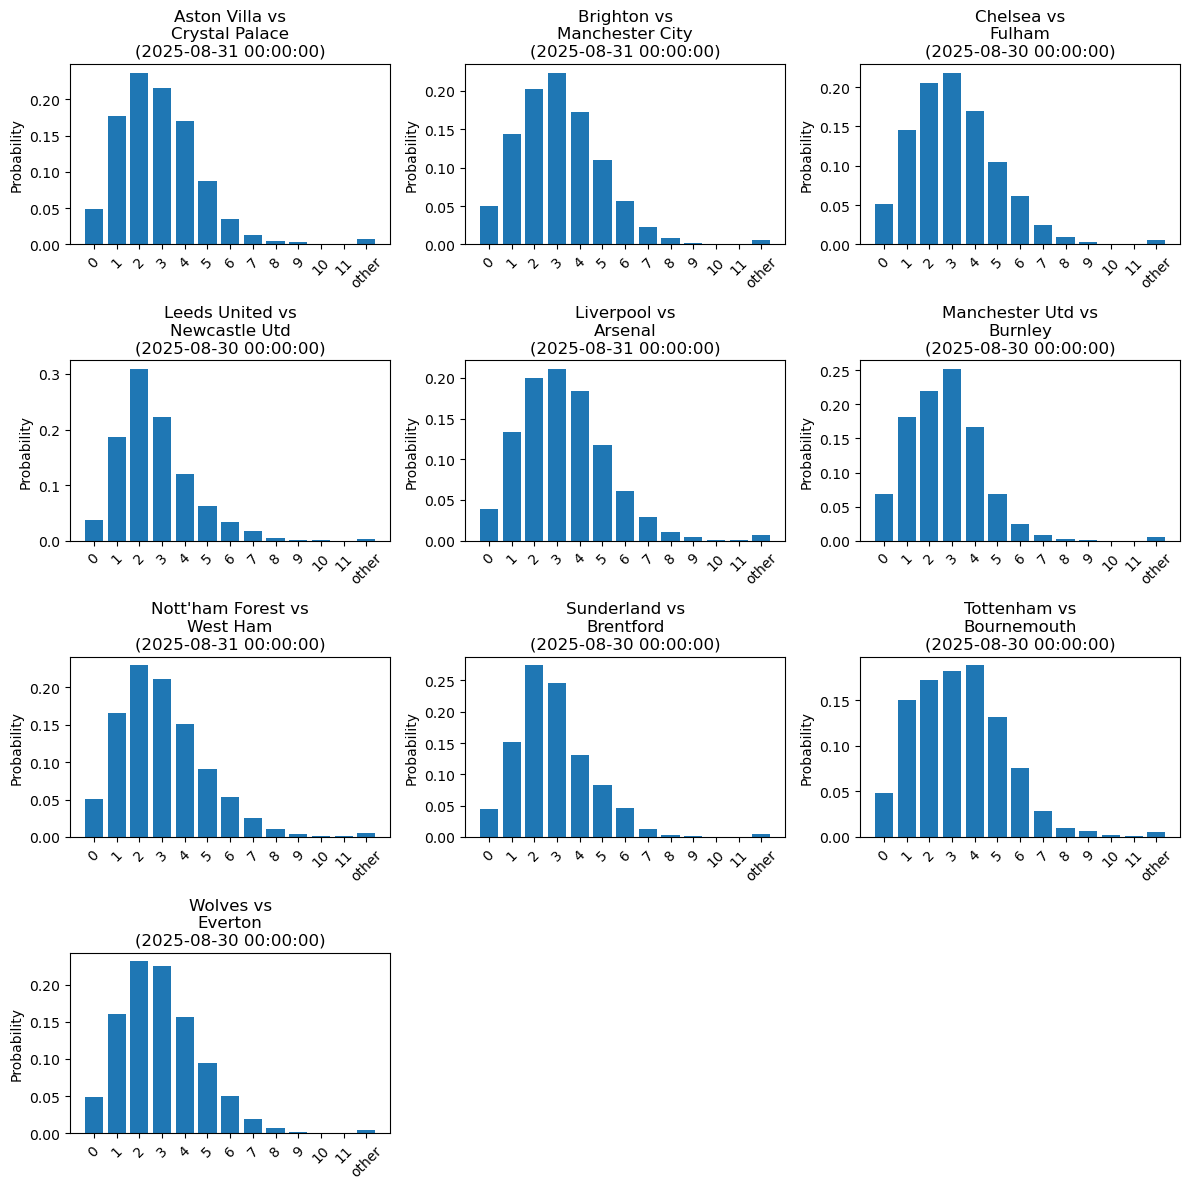

In [25]:
# The plotting function expects the 'date' column to be datetime64[ns], but in total_goals_predictions['premier_league'] it's likely object.
# Convert 'date' column to datetime
df = total_goals_predictions['premier_league'].copy()
df['date'] = pd.to_datetime(df['date'])

# Use the existing plot_predictions_distribution function
plot_predictions_distribution({'premier_league': {'total_goals': df}}, 'premier_league', 'total_goals')

In [26]:
# For each match, find the smallest total goals value where cumulative probability >= 0.5
cutoff_results = []

df = total_goals_predictions['premier_league']
goal_cols = [col for col in df.columns if col not in ['home', 'away', 'date', 'other']]
for idx, row in df.iterrows():
    probs = row[goal_cols].values
    cum_probs = probs.cumsum()
    # Find the first total goals value where cumulative probability >= 0.5
    cutoff_idx = np.searchsorted(cum_probs, 0.5)
    cutoff_goal = int(goal_cols[cutoff_idx]) if cutoff_idx < len(goal_cols) else None
    cutoff_results.append({
        'home': row['home'],
        'away': row['away'],
        'date': row['date'],
        'cutoff_goal': cutoff_goal,
        'cum_prob': cum_probs[cutoff_idx] if cutoff_idx < len(cum_probs) else None
    })

cutoff_df = pd.DataFrame(cutoff_results)
cutoff_df

,home,away,date,cutoff_goal,cum_prob
0,Aston Villa,Crystal Palace,2025-08-31,3,0.678655
1,Brighton,Manchester City,2025-08-31,3,0.619877
2,Chelsea,Fulham,2025-08-30,3,0.620134
3,Leeds United,Newcastle Utd,2025-08-30,2,0.531852
4,Liverpool,Arsenal,2025-08-31,3,0.583283
5,Manchester Utd,Burnley,2025-08-30,3,0.722428
6,Nott'ham Forest,West Ham,2025-08-31,3,0.657307
7,Sunderland,Brentford,2025-08-30,3,0.717062
8,Tottenham,Bournemouth,2025-08-30,3,0.552661
9,Wolves,Everton,2025-08-30,3,0.664394
